# CIFAR-10 SupCon Feature UMAP

Load a trained supervised contrastive model, extract test-set embeddings, and visualize them with UMAP.

In [11]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import torch
import umap
import yaml

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from src.data.cifar10 import get_cifar10_supcon_loaders
from src.models.resnet import SupConResNet
from src.training.contrastive import compute_embeddings

In [12]:
# !pip install umap-learn

In [13]:
CONFIG_PATH = REPO_ROOT / "configs" / "cifar10_supcon.yaml"

CHECKPOINT_DIR = REPO_ROOT / "checkpoints"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint dir:", CHECKPOINT_DIR)

device: cpu
checkpoint dir: /w/20252/wjcai/uq/manygp/checkpoints


In [14]:
def load_best_checkpoint(checkpoint_dir: Path, device: torch.device):
    checkpoint_paths = sorted(checkpoint_dir.glob("*.pt"))
    if not checkpoint_paths:
        raise FileNotFoundError(f"No checkpoint files found in {checkpoint_dir}")

    best_checkpoint = None
    best_path = None
    best_score = float("-inf")

    for checkpoint_path in checkpoint_paths:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        score = checkpoint.get("knn_accuracy")
        if score is None:
            continue
        if score > best_score:
            best_score = score
            best_checkpoint = checkpoint
            best_path = checkpoint_path

    if best_checkpoint is None or best_path is None:
        raise ValueError(f"No checkpoints with 'knn_accuracy' found in {checkpoint_dir}")

    return best_path, best_checkpoint


BEST_CHECKPOINT_PATH, checkpoint = load_best_checkpoint(CHECKPOINT_DIR, device)
print("best checkpoint:", BEST_CHECKPOINT_PATH)
print("best stored knn accuracy:", checkpoint.get("knn_accuracy"))

best checkpoint: /w/20252/wjcai/uq/manygp/checkpoints/cifar10_supcon_best_epoch055_knn0.9245.pt
best stored knn accuracy: 0.9245


In [15]:
data_cfg = cfg["data"]
_, _, test_loader, _, test_dataset = get_cifar10_supcon_loaders(
    data_root=data_cfg["root"],
    batch_size=256,
    num_workers=0,
    smoke_test=False,
)

model_cfg = cfg["model"]
model = SupConResNet(
    embedding_dim=model_cfg["embedding_dim"],
    projection_dim=model_cfg["projection_dim"],
    projection_hidden_dim=model_cfg["projection_hidden_dim"],
    width=model_cfg["width"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("loaded epoch:", checkpoint.get("epoch"))
print("stored knn accuracy:", checkpoint.get("knn_accuracy"))

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


loaded epoch: 55
stored knn accuracy: 0.9245


In [16]:
test_embeddings, test_labels = compute_embeddings(model, test_loader, device)
print("embedding shape:", test_embeddings.shape)
print("label shape:", test_labels.shape)

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


embedding shape: torch.Size([10000, 128])
label shape: torch.Size([10000])


In [17]:
CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
embedding_2d = reducer.fit_transform(test_embeddings.numpy())
embedding_2d.shape

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(10000, 2)

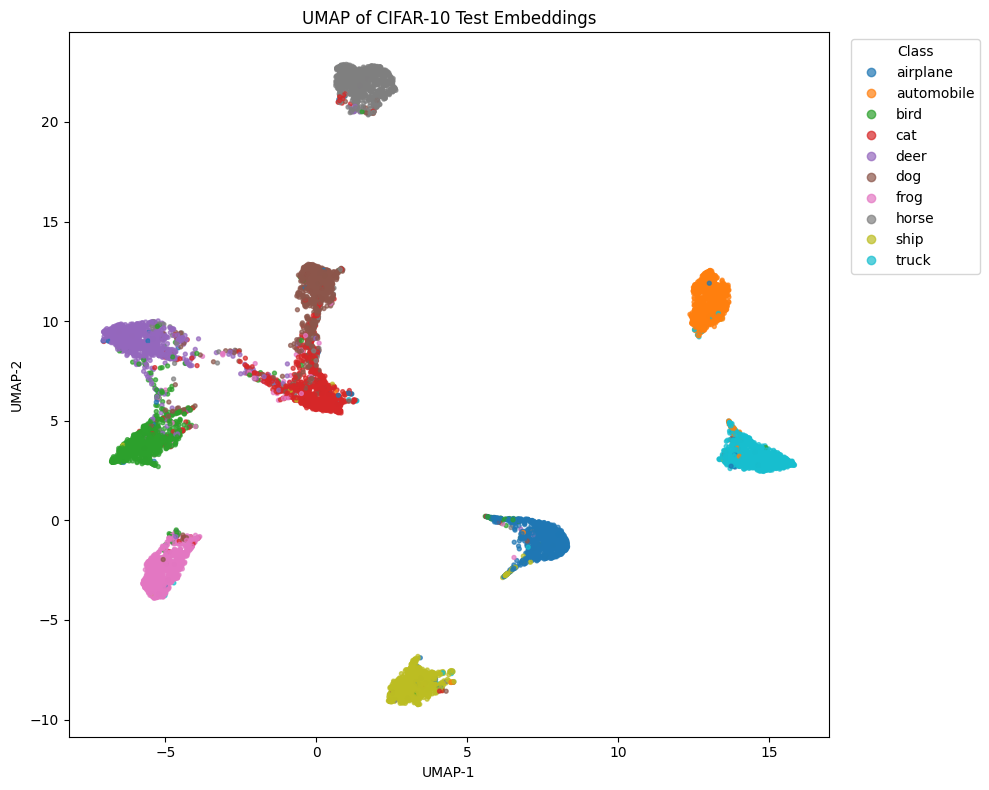

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=test_labels.numpy(),
    cmap="tab10",
    s=8,
    alpha=0.7,
)
ax.set_title("UMAP of CIFAR-10 Test Embeddings")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

handles, _ = scatter.legend_elements(num=len(CIFAR10_CLASSES))
ax.legend(handles, CIFAR10_CLASSES, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Optional: inspect separation between two classes

Set `SELECTED_CLASSES` to two class ids if you want to focus on whether two groups are well separated.

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


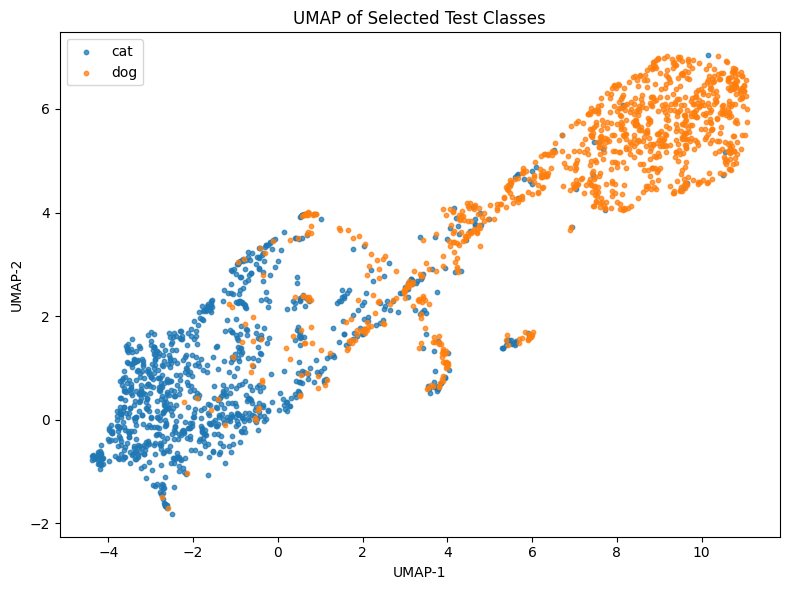

In [19]:
SELECTED_CLASSES = [3, 5]  # example: cat vs dog

mask = torch.isin(test_labels, torch.tensor(SELECTED_CLASSES))
subset_embeddings = test_embeddings[mask]
subset_labels = test_labels[mask]

subset_2d = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=42,
).fit_transform(subset_embeddings.numpy())

fig, ax = plt.subplots(figsize=(8, 6))
for class_id in SELECTED_CLASSES:
    class_mask = subset_labels.numpy() == class_id
    ax.scatter(
        subset_2d[class_mask, 0],
        subset_2d[class_mask, 1],
        s=10,
        alpha=0.75,
        label=CIFAR10_CLASSES[class_id],
    )

ax.set_title("UMAP of Selected Test Classes")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
plt.tight_layout()
plt.show()